# Not complete

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
%alias_magic t timeit
%load_ext memory_profiler

Created `%t` as an alias for `%timeit`.
Created `%%t` as an alias for `%%timeit`.


In [8]:
import demes
import pickle

import pandas as pd
import numpy as np
from momi3.utils import tqdm, downsample_jsfs, bootstrap_sample
from momi3.MOMI import Momi

In [3]:
def simulate_human_genome():
    demo = demes.load('timing_tests_yaml/8_pop_3_admix.yaml')
    sampled_demes = demo.metadata['sampled_demes']
    sample_sizes = [100, 100, 100, 2, 2, 1, 2, 2]
    momi = Momi(demo, sampled_demes, sample_sizes)
    jsfs = momi.simulate_human_genome(seed=108)
    np.savez('bootstrap_outs/jsfs_large', jsfs)
    d_jsfs = downsample_jsfs(jsfs, [6, 4, 4] + 5 * [None])
    np.savez('bootstrap_outs/down_jsfs_large', d_jsfs)

# simulate_human_genome()

In [4]:
demo = demes.load('timing_tests_yaml/8_pop_3_admix.yaml')
sampled_demes = demo.metadata['sampled_demes']
sample_sizes = demo.metadata['sample_sizes']
momi = Momi(demo, sampled_demes, sample_sizes)

In [34]:
extra_n = 100
sample_sizes = demo.metadata['sample_sizes']
for i in range(3):
    sample_sizes[i] += extra_n

In [37]:
jsfs = np.load('bootstrap_outs/jsfs_large.npz')['arr_0']
#jsfs = downsample_jsfs(jsfs, sample_sizes)

In [38]:
jsfs.shape

(101, 101, 101, 3, 3, 2, 3, 3)

In [26]:
n_SNPs = jsfs.sum()

In [27]:
n_SNPs = int(1e6)

In [28]:
jsfs = bootstrap_sample(jsfs, n_SNPs=n_SNPs, seed=int(108))

In [31]:
jsfs.sum()

1000000

In [49]:
p = jsfs[nonzeros.T]

AttributeError: 'list' object has no attribute 'T'

In [48]:
p

5222191.365608175

In [45]:
p.shape

(19266, 8, 5, 5, 3, 3, 2, 3, 3)

In [41]:
jsfs.dataaa

In [35]:
jsfs

array([[[[[[[[5.22219137e+06, 4.90925687e+03, 9.98861739e+05],
             [9.08156336e+04, 0.00000000e+00, 9.16542725e+03],
             [4.66087975e+04, 0.00000000e+00, 1.08339677e+04]],

            [[7.56858299e+04, 0.00000000e+00, 7.84394456e+03],
             [2.00946354e+03, 0.00000000e+00, 4.89302139e+02],
             [2.77946053e+03, 2.39701638e-04, 7.26555140e+02]]],


           [[[5.59475715e+03, 0.00000000e+00, 7.17875608e+01],
             [2.33785681e+01, 0.00000000e+00, 5.86547233e-01],
             [3.74741602e+01, 0.00000000e+00, 7.75043659e-01]],

            [[4.86883262e+01, 0.00000000e+00, 1.32517067e+01],
             [7.99845455e+00, 0.00000000e+00, 1.93228482e+00],
             [1.19859185e+01, 0.00000000e+00, 2.15317252e+00]]],


           [[[5.67566755e+04, 6.22669191e-01, 3.17316608e+03],
             [7.07886608e+02, 0.00000000e+00, 2.22610791e+02],
             [9.52672658e+02, 0.00000000e+00, 2.66989667e+02]],

            [[1.61321208e+03, 0.00000000e

In [28]:
x.

In [27]:
x

In [11]:
jsfs = momi._bootstrap_sample(jsfs,100)

AttributeError: 'NpzFile' object has no attribute 'sum'

In [110]:
momi._bootstrap_sample(jsfs, seed=10)


AttributeError: 'memoryview' object has no attribute 'sum'

In [69]:
(x != 0).sum()

14769

In [75]:
ts, sampled_ids = msprime_chromosome_simulator(demo, demo.metadata['sampled_demes'], demo.metadata['sample_sizes'], 1e7, 1e-8, 1e-8, seed=108)

In [77]:
sfs = ts.allele_frequency_spectrum(sample_sets=sampled_ids, polarised=True, span_normalise=False)

In [80]:
jsfs = jsfs.todense()

In [86]:
for i, j in zip(sfs[~np.isclose(sfs, jsfs)], jsfs[~np.isclose(sfs, jsfs)]):
    print(i, j)

3679.0 3674
26.0 25
237.0 236
1.0 2
213.0 212
59.0 58
0.0 1
814.0 813
18.0 17
0.0 1
9.0 8
31.0 32
215.0 213
3442.0 3435
66.0 68
9.0 10
1358.0 1356
4.0 3
740.0 741
0.0 1
3.0 2
155.0 156
3.0 4
181.0 180
196.0 197


array([3674,   25,  236,    2,  212,   58,    1,  813,   17,    1,    8,
         32,  213, 3435,   68,   10, 1356,    3,  741,    1,    2,  156,
          4,  180,  197], dtype=int32)

In [82]:
i = 125
with open(f'bootstrap_outs/momi2OOA_bs_{i}.pickle', 'rb') as f:
    ret = pickle.load(f)

In [83]:
ret

{'eta_11': 2703.6570065616947,
 'eta_15': 4431.332645758342,
 'eta_8': 7461.282795166779,
 'pi_0': 0.011283220328547785,
 'pi_1': 0.0003570541719888438,
 'pi_2': 0.04732593047931782,
 'tau_1': 60.0641166326194}

In [75]:
ret

{'eta_11': 2703.068899191527,
 'eta_15': 4431.460623227519,
 'eta_8': 7465.629220843947,
 'pi_0': 0.011425179496321864,
 'pi_1': 0.00012153261987276897,
 'pi_2': 0.049123442962179395,
 'tau_1': 58.30890772904746}

In [103]:
df = []
for i in range(1, 251):
    with open(f'bootstrap_outs/momi2OOA_bs_{i}.pickle', 'rb') as f:
        ret = pickle.load(f)
    df.append(ret)

In [104]:
df = pd.DataFrame(df)

In [4]:
import demes, demesdraw

In [5]:
demo = demes.load('timing_tests_yaml/8_pop_3_admix.yaml')

In [6]:
from momi3.MOMI import Momi

/mnt/turbo/eneswork/jthlab/momi3/src/momi3/utils.py:22: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [41]:
sparse.save_npz('bootstrap_outs/jsfs.npz', jsfs)

NameError: name 'sparse' is not defined

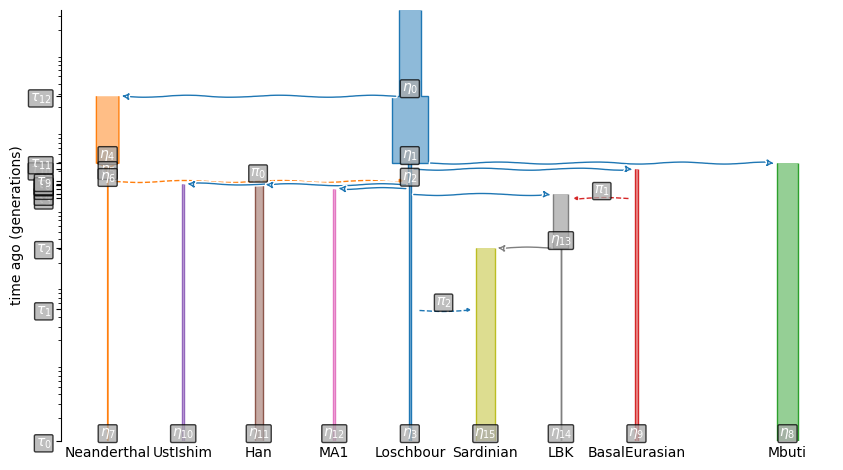

In [28]:
momi._default_params.tubes(False, True, log_time=True)

In [105]:
a = 0.05
qs = df.apply(lambda x: np.quantile(x, (a / 2, 1 - a / 2))).T
qs.rename(columns={0: f'{a / 2}', 1: f'{1 - a / 2}'}).round(3)

,0.025,0.975
eta_0,8511.530,9996.490
eta_1,13703.083,15636.279
eta_10,811.967,1149.703
eta_11,2690.889,3666.936
eta_12,1918.400,1949.896
eta_13,3635.701,10099.341
eta_14,16.572,73.301
eta_15,2667.491,330271.426
eta_2,894.281,1519.230
eta_3,817.684,1143.814


In [40]:
import demes
import numpy as np

from momi3.MOMI import Momi

import pickle
import os, sys

In [3]:
sys.path.append('../momi3/tests/')

In [4]:
from demos import ThreeDemes

In [6]:
import sys
import pickle
sys.path.append('slurm_performance_tests/')

In [7]:
from time_8_pop_admixture import Return8

In [80]:
with open('/tmp/momi2OOA_23d087bcaa3b43fcbb1e31f450c16475e4861b2126114541ff8cc7c4a3be2a59.pickle', 'rb') as f:
    ret = pickle.load(f)

In [81]:
g = ret.gradient_values

In [82]:
y = np.array(ret.esfs)
y /= y.sum()

In [83]:
with open('/tmp/momi2OOA_60d87da05ad8e265cc56a6badd1dff29f1154cbd26a7c892410ebd9eb26488a1.pickle', 'rb') as f:
    ret = pickle.load(f)

In [84]:
go = ret.gradient_values

In [95]:
print('Relative Percent error:')
for i in go:
    g1 = g[i]
    g2 = go[i]
    if g1 / g2 < 0:
        raise ValueError('different signs')
    else:
        error = 100 * (1-g1/g2)
    
    print(f'{i}:\t{error:.2f}')

Relative Percent error:
eta_0:	-4.38
tau_12:	-1.70
eta_1:	-1.65
eta_2:	-0.08
eta_3:	-0.05
eta_4:	-0.51
eta_6:	0.97
tau_6:	0.97
eta_5:	0.88
eta_7:	0.06
eta_8:	-0.20
tau_11:	-0.08
eta_9:	-0.21
tau_10:	-0.01
eta_10:	-0.03
tau_8:	-0.17
eta_11:	-0.07
tau_7:	0.37
eta_12:	-16.75
tau_5:	-0.10
tau_2:	-0.00
eta_13:	-0.06
eta_14:	-0.00
tau_4:	-0.07
eta_15:	-0.06
pi_0:	-0.54
tau_9:	-0.33
pi_1:	-0.13
tau_3:	-0.08
pi_2:	2.15
tau_1:	0.25


In [73]:
with open('/tmp/momi2OOA_664d78892a66dd2fef155320f8759b69f279b74fdafc97ad397ff7cde1aaaa28.pickle', 'rb') as f:
    ret = pickle.load(f)

In [74]:
m2 = np.array(ret.esfs)
m2 /= m2.sum()

In [75]:
np.sum(np.abs(np.array(m2) - np.array(y)))

0.0025225109870175557

In [68]:
np.sum(np.abs(np.array(y) - np.array(m2)))

759.4865438469037

In [31]:
sample_sizes = [26, 25, 20, 2, 2, 1, 2, 2]

In [57]:
momi = Momi(demo, sampled_demes, sample_sizes, jitted=True)

In [58]:
jsfs = momi.simulate(1000, seed=108)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [59]:
params = momi._default_params
params.set_train_all_pis(True)
params.set_train('tau_1', True)
params.set_train('tau_3', True)
params.set_train('tau_9', True)

In [60]:
momi.loglik_with_gradient(params, jsfs)

(-1221.1669921875,
 {'pi_0': -179.70953369140625,
  'tau_9': 0.00894438847899437,
  'pi_1': -54.02708435058594,
  'tau_3': 0.0015645027160644531,
  'pi_2': -8.969367980957031,
  'tau_1': 0.0006282951799221337})

In [62]:
%%time
momi.loglik_with_gradient(params, jsfs)

CPU times: user 20.2 s, sys: 13.1 s, total: 33.3 s
Wall time: 1.93 s


(-1221.1669921875,
 {'pi_0': -179.70953369140625,
  'tau_9': 0.00894438847899437,
  'pi_1': -54.02708435058594,
  'tau_3': 0.0015645027160644531,
  'pi_2': -8.969367980957031,
  'tau_1': 0.0006282951799221337})

In [63]:
bounds = momi.bound_sampler(params, 100000)

Time(3832.0) Lift {'Mbuti': 10, 'Han': 25, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2016.0) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2000.0) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(1348.0) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2, 'BasalEurasian': 2}
Time(2060.0) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2, 'BasalEurasian': 2}
Time(1796.0) Lift {'Mbuti': 10, 'Han': 8, 'Sardinian': 20, 'Loschbo

In [64]:
momi_b = momi.bound(bounds)
momi_b.loglik_with_gradient(params, jsfs)

(-1221.585693359375,
 {'pi_0': -177.55245971679688,
  'tau_9': 0.008902564644813538,
  'pi_1': -56.70165252685547,
  'tau_3': 0.0028001070022583008,
  'pi_2': -5.419898986816406,
  'tau_1': 0.0006193254957906902})

In [66]:
%%time
momi_b.loglik_with_gradient(params, jsfs)

CPU times: user 960 ms, sys: 943 ms, total: 1.9 s
Wall time: 90.8 ms


(-1221.585693359375,
 {'pi_0': -177.55245971679688,
  'tau_9': 0.008902564644813538,
  'pi_1': -56.70165252685547,
  'tau_3': 0.0028001070022583008,
  'pi_2': -5.419898986816406,
  'tau_1': 0.0006193254957906902})

In [9]:
d = dict(zip(sampled_demes, 7 * [0] + [1]))

In [10]:
#momi.sfs_entry(d)

In [11]:
params = momi._default_params

In [12]:
params.set_train_all_pis(True)
params.set_train('tau_1', True)
params.set_train('tau_3', True)
params.set_train('tau_9', True)

In [13]:
#params.tubes(True, True, log_time=True, hide_non_inferreds=True, tau_font_size=0.)

In [22]:
df = {}
for i in range(1, 251):
    with open(f'bootstrap_outs/momi2OOA_bs_{i}.pickle', 'rb') as f:
        ret = pickle.load(f)
        for i in ret:
            try:
                df[i].append(ret[i])
            except:
                df[i] = [ret[i]]

In [23]:
SE = {i: np.std(df[i]) for i in df}
PE = {i: np.mean(df[i]) for i in df}

In [24]:
bounds = momi.bound_sampler(params, 1000, SE)

Time(3832.0) Lift {'Mbuti': 8, 'Han': 10, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2016.0) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2000.0) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1}
Time(1348.0) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(2060.0) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(1796.0) Lift {'Mbuti': 8, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 

In [30]:
bounds

{Lift(bounds=None, t0=Time(0.0), t1=Time(3832.0), epochs=frozendict.frozendict({'Mbuti': 0}), migrations=frozendict.frozendict({})): {'Mbuti': 8,
  'Han': 10,
  'Sardinian': 10,
  'Loschbour': 2,
  'LBK': 2,
  'MA1': 1,
  'UstIshim': 2,
  'Neanderthal': 2},
 Lift(bounds=None, t0=Time(0.0), t1=Time(2016.0), epochs=frozendict.frozendict({'Han': 0}), migrations=frozendict.frozendict({})): {'Mbuti': 8,
  'Han': 6,
  'Sardinian': 10,
  'Loschbour': 2,
  'LBK': 2,
  'MA1': 1,
  'UstIshim': 2,
  'Neanderthal': 2},
 Lift(bounds=None, t0=Time(0.0), t1=Time(49.2), epochs=frozendict.frozendict({'Sardinian': 0}), migrations=frozendict.frozendict({})): {'Mbuti': 8,
  'Han': 6,
  'Sardinian': 10,
  'Loschbour': 2,
  'LBK': 2,
  'MA1': 1,
  'UstIshim': 2,
  'Neanderthal': 2},
 Lift(bounds=None, t0=Time(0.0), t1=Time(49.2), epochs=frozendict.frozendict({'Loschbour': 3}), migrations=frozendict.frozendict({})): {'Mbuti': 8,
  'Han': 6,
  'Sardinian': 10,
  'Loschbour': 2,
  'LBK': 2,
  'MA1': 1,
  'UstI

In [28]:
momi_b = momi.bound(bounds)
momi_b.sfs_entry(d)

TypeError: mul got incompatible shapes for broadcasting: (2,), (3,).

In [43]:
SNR = {i: PE[i] / SE[i] for i in df}

In [44]:
SNR

{'pi_0': 1.6101536028747816,
 'pi_1': 1.0747593935590856,
 'pi_2': 0.5797691257160008,
 'tau_1': 1.1739868588378557,
 'tau_3': 5.940550038741574,
 'tau_9': 10.286973547875988}

In [34]:
a = 0.05
np.quantile(x, [a / 2, 1 - a / 2])

array([8.63478283e-06, 1.61442445e-02])

0.01878086507461807

In [70]:
jsfs = momi.simulate_chromosome(1e7, 1e-8, 1e-8)

In [75]:
transformed = True
theta_train_dict = params.theta_train_dict(transformed)
train_keys = tuple(theta_train_dict)
train_vals = list(theta_train_dict.values())

def obj_for_scipy(train_vals, train_keys=train_keys):
    theta_train_dict = {key: float(val) for key, val in zip(train_keys, train_vals)}

    val, grad = momi.negative_loglik_with_gradient(
        params, jsfs, theta_train_dict, transformed=transformed
    )

    return val, np.array([grad[i] for i in train_keys])

In [77]:
obj_for_scipy(train_vals)

(112661.921875,
 array([ 635.61450195,  193.83003235,    9.95904732, -124.04050446,
        -648.63720703,  953.04882812,  152.78189087, -166.53042603,
         146.66137695]))

In [79]:
optimizer_options = dict()
method = 'SLSQP'

In [81]:
from scipy import optimize

In [83]:
res = optimize.minimize(
    fun=obj_for_scipy,
    x0=train_vals,
    jac=True,
    method=method,
    options=optimizer_options
)

In [84]:
res.fun

111683.6328125

In [92]:
lr = 0.5
method="trust-constr"
res = optimize.minimize(
    fun=obj_for_scipy,
    x0=train_vals,
    jac=True,
    method=method,
    options=dict(initial_tr_radius=lr, verbose=2, maxiter=5)
)

| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   1   |   0   | +1.1266e+05 | 5.00e-01 | 9.53e+02 | 0.00e+00 |
|   2   |   2   |   1   | +1.1219e+05 | 1.00e+00 | 4.78e+02 | 0.00e+00 |
|   3   |   3   |   3   | +1.1188e+05 | 4.54e+00 | 1.97e+02 | 0.00e+00 |
|   4   |   4   |   6   | +1.1179e+05 | 4.54e+00 | 9.50e+01 | 0.00e+00 |
|   5   |   5   |   9   | +1.1177e+05 | 4.54e+00 | 5.50e+01 | 0.00e+00 |

The maximum number of function evaluations is exceeded.
Number of iterations: 5, function evaluations: 5, CG iterations: 9, optimality: 5.50e+01, constraint violation: 0.00e+00, execution time:  9.8 s.


In [95]:
opt_params = dict(zip(train_keys, res.x))

In [96]:
params.set_optimization_results(opt_params)

In [101]:
import pickle

In [114]:
rets = []
for i in range(1, 251):
    with open(f'bootstrap_outs/momi2OOA_bs_{i}.pickle', 'rb') as f:
        ret = pickle.load(f)
    rets.append(ret)

In [126]:
rets = []
for i in range(1, 251):
    with open(f'bootstrap_outs/momi2OOA_bs_{i}.pickle', 'rb') as f:
        ret = pickle.load(f)
    rets.append(ret)
rets = pd.DataFrame(rets)

In [127]:
theta_train_hat = rets.mean().to_dict()
scale = rets.std().to_dict()

In [129]:
for key in scale:
    mu = theta_train_hat[key]
    si = scale[key]
    print(mu - 2 * si, mu + 2 * si)

2688.886003454885 2708.855655159159
4281.659300928112 4536.4834437885065
7443.229874931724 7486.7450391135835
0.011210152492455657 0.011526615061812163
5.879813002203756e-06 0.0003916832624639128
0.043341793052815124 0.05490982901303681
38.527258943125275 75.26431569526986


In [121]:
std_y = rets.std()['tau_1']

In [134]:
a = {'a':2}

In [137]:
sample_sizes

[6, 4, 4, 2, 2, 1, 2, 2]

In [138]:
jsfs = np.load('bootstrap_outs/jsfs_large.npz')['arr_0']
jsfs = downsample_jsfs(jsfs, sample_sizes)

In [139]:
from momi3.utils import bootstrap_sample

ImportError: cannot import name 'bootstrap_sample' from 'momi3.utils' (/mnt/turbo/eneswork/jthlab/momi3/src/momi3/utils.py)

In [ ]:
jsfs = bootstrap_sample(jsfs, n_SNPs=n_SNPs, seed=int(RANDOM_SEED))

In [133]:
values

{'eta_11': [],
 'eta_15': [],
 'eta_8': [],
 'pi_0': [],
 'pi_1': [],
 'pi_2': [],
 'tau_1': []}

In [106]:
params = momi._default_params

In [112]:
params['pi_2']

0.0317

In [56]:
params

Parameter,Value,Infer
┦,1.82e+04,❌
𗎆,1.92e+03,❌
𗎇,6.3e+03,❌
𗎈,1.92e+03,❌
𗎉,1.2e+04,❌
𗎊,75.7,❌
𗎋,1.5e+04,❌
┧,2.91e+04,❌
┨,2.34e+03,❌
┩,1.92e+03,❌


In [36]:
%debug

> /mnt/turbo/eneswork/jthlab/momi3/src/momi3/Params.py(919)tubes()
    917                     ret.get_yticklabels()[i].set_color(text_params[key]["color"])
    918                     ret.get_yticklabels()[i].set_bbox(prms_box_current)
--> 919                     ret.get_yticklabels()[i].set_labelsize(10.)
    920 
    921     def _init_Theta(

ipdb> dir(ret.get_yticklabels()[i])
['_PROPERTIES_EXCLUDED_FROM_SET', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_agg_filter', '_alias_map', '_alpha', '_animated', '_axes', '_bbox_patch', '_cached', '_callbacks', '_clipon', '_clippath', '_cm_set', '_color', '_default_contains', '_fontproperties', '_get_clipping_extent_bbox', '_get_d

In [22]:
bounds = momi.bound_sampler(momi._default_params, [], 1000)

Time(3832.0) Lift {'Mbuti': 9, 'Han': 10, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2016.0) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2000.0) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1}
Time(1348.0) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(2060.0) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(1796.0) Lift {'Mbuti': 9, 'Han': 6, 'Sardinian': 10, 'Loschbour': 2, 

In [15]:
d = dict(zip(sampled_demes, 7 * [0] + [1]))

In [16]:
momi.sfs_entry(d)

Array(347.6674, dtype=float32)

Time(3832.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2016.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(49.2) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 2}
Time(2000.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1}
Time(1348.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(2060.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2, 'MA1': 1, 'UstIshim': 2, 'Neanderthal': 1, 'BasalEurasian': 1}
Time(1796.0) Lift {'Mbuti': 5, 'Han': 4, 'Sardinian': 4, 'Loschbour': 2, 'LBK': 2,

In [12]:
momi_b = momi.bound(bounds)

Mbuti 6
Han 4
Sardinian 4
Loschbour 4
Neanderthal 4
BasalEurasian 4
UstIshim 4
MA1 4
LBK 4
Neanderthal 4
Loschbour 8
Sardinian 4
LBK 8
Loschbour 8
BasalEurasian 12
Loschbour 8
LBK 8
BasalEurasian 12
Loschbour 12
BasalEurasian 12
Loschbour 16
BasalEurasian 12
Loschbour 20
BasalEurasian 12
Loschbour 24
Neanderthal 28
BasalEurasian 12
Loschbour 24
Neanderthal 28
Loschbour 28
Neanderthal 28
Loschbour 34
Loschbour 38
Mbuti 6
Han 4
Sardinian 4
Loschbour 4
Neanderthal 4
BasalEurasian 4
UstIshim 4
MA1 4
LBK 4
Neanderthal 1


IndexError: index 0 is out of bounds for axis 1 with size 0

In [22]:
from momi3.events.lift import _aux_single

In [23]:
_aux_single(1)

IndexError: index 0 is out of bounds for axis 1 with size 0

In [94]:
params['tau_11']

KeyError: 'tau_11'